In [1]:
import nltk
import re
import keras
import pandas as pd
import numpy as np

# !! GLove embedding Download

For this project, glove embedding is used. The embeddings can be download from the following link: "http://nlp.stanford.edu/data/glove.6B.zip"

todo:
1. download the embedding .zip file
2. extract the .zip file and either do adjustment to the **path_pretrained_embedding** variable in the next snippet or
3. copy **glove.6B.300d.txt** and paste it in the same folder as the notebook.


if none works, please use a random embedding as wishes (IMDB as in excercise), by doing minimal adjustment in the **path_pretrained_embedding** variable. thanks

Settings the paths for necessary data/files/extensions and global variable

In [ ]:
path_test = "./btc_tweets_test.parquet.gzip"
path_train = "./btc_tweets_train.parquet.gzip"
path_pretrained_embedding = "./glove.6B.300d.txt"

# 1. Text Data Processing

In [3]:
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup as bs

Helper functions text processing for the datasets

In [4]:
def clean_df(input_df):
    stop_words = set(stopwords.words('english'))


    df = input_df[['content', 'sentiment']].copy()
    # print(output_df.shape)
    df['content'] = df['content'].astype(str)

    # remove URLs and HTML content
    df['content'] = df['content'].apply(lambda x: re.sub(r'https?://\S+|www\.\S+', '', x))
    df['content'] = df['content'].apply(lambda x: bs(x).get_text())

    # remove hastags and mentions
    '''
    Should the hashtags stay? just take out the #-symbol instead?
    '''
    df['content'] = df['content'].apply(lambda x: re.sub(r'[@#$]\w+', '', x))
    # Remove non-alphabetic characters
    df['content'] = df['content'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', x))
    # Remove extra whitespace and lowercase
    df['content'] = df['content'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())
    df['content'] = df['content'].apply(lambda x: x.lower())

    # convert sentiment to 
    df['sentiment'] = df['sentiment'].map({True: 1, False: 0}).astype(int)

    # tokenization and stopword removal
    df['content'] = df['content'].apply(lambda x: nltk.word_tokenize(x))
    df['content'] = df['content'].apply(lambda x: [word for word in x if word not in stop_words])

    return df


def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
                
    pos=tag_dict.get(tag,wordnet.NOUN)

    return pos


Processing data

In [5]:
raw_test = pd.read_parquet(path_test)
raw_test.to_csv("test.csv", index=False)
raw_train = pd.read_parquet(path_train)

# print(raw_test)
'''
Processing for the test set
'''
test = clean_df(raw_test)
# test= token_stopword(test)

'''
Processing for the train set
'''
train = clean_df(raw_train)
# train= token_stopword(train)

'''
Lemmatization
'''
lemmatizer = WordNetLemmatizer()
test['content'] = test['content'].apply(lambda x: [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in x])
train['content'] = train['content'].apply(lambda x: [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in x])

# 2. Vectorizer, Classifier and Dictionary based Sentiment Analysis

In [6]:
from xgboost import XGBClassifier
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import recall_score,precision_score,roc_auc_score, accuracy_score

Helper functions for the sub-task 2

In [7]:
class TextClassifier:
    def __init__(self, sentiment_dict=None):
        self.vectorizers = {
            'tfidf': TfidfVectorizer(
                analyzer='word',
                tokenizer=lambda doc: doc,
                preprocessor=lambda doc: doc,
                token_pattern=None),
            'count': CountVectorizer(
                analyzer='word',
                tokenizer=lambda doc: doc,
                preprocessor=lambda doc: doc,
                token_pattern=None)
        }
        self.sentiment_dict = sentiment_dict
        self.results = {}
        self.models = {
            'logit': LogisticRegression(),
            'xgb': XGBClassifier(n_estimators=10)
        }


    def fit_transform(self, vectorizer, x_train):
        return vectorizer.fit_transform(x_train)
    
    def transform(self, vectorizer, x_test):
        return vectorizer.transform(x_test)
    
    def train_and_evaluate(self, x_train, y_train, x_test, y_test):
        results = {}
        
        for vec_name, vectorizer in self.vectorizers.items():
            # Vectorize the data
            x_train_vec = self.fit_transform(vectorizer, x_train)
            x_test_vec = self.transform(vectorizer, x_test)
            
            for model_name, model in self.models.items():
                # Train the model
                model.fit(x_train_vec, y_train)
                y_pred = model.predict(x_test_vec)
                y_proba = model.predict_proba(x_test_vec)[:, 1]
           
                
                # Store the results with combined key name
                result_key = f"{model_name}_{vec_name}"
                results[result_key] = {
                    'recall': recall_score(y_true=y_test, y_pred=y_pred),
                    'precision': precision_score(y_true=y_test, y_pred=y_pred),
                    'accuracy' : accuracy_score(y_true=y_test, y_pred=y_pred),
                    'roc_auc': roc_auc_score(y_true=y_test, y_score=y_proba),
                    'neutral_count': 0

                }
        
        self.results = results
        return self.results


In [8]:
x_train= train['content']
y_train = train['sentiment']

x_test = test['content']
y_test = test['sentiment']

classifier = TextClassifier()
result = classifier.train_and_evaluate(x_train, y_train, x_test, y_test)

Dictionary for word per word comparison

In [9]:
# Vader sentiment dictionary
nltk.download('vader_lexicon')
sid = SentimentIntensityAnalyzer()
vader_dict = sid.lexicon


# crypto specific sentiment dictionary addition
crypto_dict = {
    # Positive terms
    "bull": 2,
    "bullish": 2,
    "bullrun": 2,
    "pump": 1.5,
    "rally": 1.5,
    "breakout": 1.5,
    "worth": 1,
    "adoption": 1.5,
    "support": 0.5,
    "btfd": 1,
    "uptrend": 1.5,
    "ath": 2,
    "hodl": 2,
    "hodler": 1.5,
    "moon": 2, 
    "mooning": 2,
    "rocket": 1.5,
    "diamond": 1, 
    "bullmarket": 2,
    "lambo": 1.5,
    "financial freedom": 1.5,
    "halving": 1,
    "green": 1,
    "higher": 1,
    "opportunity": 1,
    "giveaway": 0.5,
    "gem": 1.5,
    "rewards": 1,
    "airdrop": 0.5,
    "staking": 0.5,
    "trust": 1,
    "excited": 1,
    "real yield": 1,
    "parabolic": 1.5,
    "decentralization": 1,
    "freedom": 1.5,
    "shibarium": 1,   
    "terraport": 0.5,
    "lunc burn": 1, 
    "magic eden": 0.5,
    "bitapes": 0.5,
    
    # Negative terms
    "bear": -2,
    "bearish": -2,
    "crash": -2,
    "dump": -1.5,
    "dip": -0.5,
    "resistance": -0.5,
    "correction": -1,
    "fud": -2,
    "scam": -2,
    "ponzi": -2,
    "bubble": -1.5,
    "rug": -2,
    "rugpull": -2,
    "rekt": -2, 
    "bagholder": -1.5,
    "selloff": -1.5,
    "capitulation": -2,
    "manipulation": -1.5,
    "ban": -2,
    "regulation": -1,  
    "trouble": -1,
    "hack": -2,
    "fear": -1.5,
    "bearmarket": -2,
    "red": -1,
    "lower": -1,
    "fraud": -2,
    "nuke": -1.5,
    "investigation": -1,
    "seized": -1,
    "jail": -1,
    "ceasing": -1.5,
    "downtrend": -1.5,
    "crisis": -1.5,
    "anti": -1,
    "unbankable": -1,
    "tax": -0.5,
    "silk road": -0.5
}
combined_dict = {}
combined_dict.update(vader_dict)
combined_dict.update(crypto_dict)



# Laughran Mcdonald sentiment dictionary
lm_pos = pd.read_csv('https://raw.githubusercontent.com/AmeriFinn/NLP-Projects/refs/heads/main/LoughranMcDonald_Positive.csv')
lm_pos.columns = ['token']
lm_pos['score'] = 1
lm_neg = pd.read_csv('https://raw.githubusercontent.com/AmeriFinn/NLP-Projects/refs/heads/main/LoughranMcDonald_Negative.csv')
lm_neg.columns = ['token']
lm_neg['score'] = -1
lm_pos['token'] = lm_pos['token'].str.lower()
lm_neg['token'] = lm_neg['token'].str.lower()
lm_dict = pd.concat([lm_pos, lm_neg]).set_index('token')['score'].to_dict()

dict_list = {
    'lm' : lm_dict,
    'vader_base' : vader_dict,
    'vader_updated' : combined_dict,
}

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/benedikt/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Brute text to dictionary comparison

In [10]:
for name, sentiment_dict in dict_list.items():
    y_pred = []
    predictions = []

    sent_analysis = pd.DataFrame(x_train).reset_index()
    sent_analysis['sentiment_score'] = 0
    sent_analysis['predicted_sentiment'] = None

    for idx, content in enumerate(sent_analysis['content']):
        score = sum(sentiment_dict.get(token, 0) for token in content)
        
        # Store the score in the DataFrame
        sent_analysis.loc[idx, 'sentiment_score'] = score
        
        # Assign sentiment class based on score
        if score > 0:
            pred_sentiment = 1
        elif score < 0:
            pred_sentiment = 0
        else:
            pred_sentiment = 99
        
        sent_analysis.loc[idx, 'predicted_sentiment'] = pred_sentiment 

        predictions.append(pred_sentiment)

    valid_indices = [i for i, pred in enumerate(predictions) if pred != 99]

    if valid_indices:
        filtered_preds = [predictions[i] for i in valid_indices]
        filtered_true = [y_train.iloc[i] for i in valid_indices]
        
        result[name] = {
            'recall': recall_score(y_true=filtered_true, y_pred=filtered_preds),
            'precision': precision_score(y_true=filtered_true, y_pred=filtered_preds),
            'accuracy' : accuracy_score(y_true=filtered_true, y_pred=filtered_preds),
            'neutral_count': predictions.count(99)
        }
    else:
        result[name] = {
            'recall': 'N/A - all neutral',
            'precision': 'N/A - all neutral',
            'accuracy' : accuracy_score(y_true=filtered_true, y_pred=filtered_preds),
            'neutral_count': predictions.count(99)
        }


/var/folders/c2/nw3f3w191x147lw_j8x81st80000gn/T/ipykernel_48825/254173605.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.7' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sent_analysis.loc[idx, 'sentiment_score'] = score
/var/folders/c2/nw3f3w191x147lw_j8x81st80000gn/T/ipykernel_48825/254173605.py:13: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.7' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sent_analysis.loc[idx, 'sentiment_score'] = score


Vader built-in function

In [11]:
analyzer = SentimentIntensityAnalyzer()
sent_analysis = pd.DataFrame(x_train).reset_index()
sent_analysis['sentiment_score'] = 0
sent_analysis['predicted_sentiment'] = None
predictions = []
y_proba = []
df_scores = pd.DataFrame()


for idx, content in enumerate(sent_analysis['content']):
    content_str = ' '.join(content)
    vs = analyzer.polarity_scores(content_str)
    sentiment_scores = {k: v for k, v in vs.items() if (k != 'compound' and k != 'neu')}

    sentiment = max(sentiment_scores, key=sentiment_scores.get)
    score = sentiment_scores[sentiment]


    if sentiment == 'pos':
        pred_sentiment = 1
    elif sentiment == 'neg':
        pred_sentiment = 0

    sent_analysis.loc[idx, 'predicted_sentiment'] = pred_sentiment 
    sent_analysis.loc[idx, 'sentiment_score'] = score

    predictions.append(pred_sentiment)
    y_proba.append(score)


df_scores['vader_BuildIn_Func'] = [recall_score(y_true=y_train, y_pred=predictions), precision_score(y_true=y_train, y_pred=predictions), accuracy_score(y_true=y_train, y_pred=predictions), roc_auc_score(y_true=y_train, y_score=y_proba)]
result["vader_BuildIn_Func"] = {
    'recall': recall_score(y_true=y_train, y_pred=predictions),
    'precision': precision_score(y_true=y_train, y_pred=predictions),
    'accuracy' : accuracy_score(y_true=y_train, y_pred=predictions),
    'roc_auc': roc_auc_score(y_true=y_train, y_score=y_proba),
    'neutral_count': 0
}

/var/folders/c2/nw3f3w191x147lw_j8x81st80000gn/T/ipykernel_48825/2218304952.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.231' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  sent_analysis.loc[idx, 'sentiment_score'] = score


## Result for Dictionary based Analysis

In [12]:
result_df = pd.DataFrame(result).T
display(result_df)

,recall,precision,accuracy,roc_auc,neutral_count
logit_tfidf,1.000000,0.811245,0.812000,0.856410,0.0
xgb_tfidf,0.990099,0.824742,0.822000,0.691032,0.0
logit_count,0.972772,0.852495,0.842000,0.846122,0.0
xgb_count,0.987624,0.826087,0.822000,0.751715,0.0
lm,0.670185,0.933824,0.720703,NaN,988.0
vader_base,0.873762,0.890290,0.815430,NaN,476.0
vader_updated,0.878021,0.895540,0.822080,NaN,404.0
vader_BuildIn_Func,0.578689,0.886935,0.597333,0.491658,0.0


# 3. Advanced word embedding and FNN to choose one embedding for moving forward

In [13]:
from openTSNE import TSNE
from keras import Sequential
import seaborn as sns
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from keras.layers import TextVectorization

vocab_size = 5000
seq_length = 100
embeddings_dimension=300

Helper Functions for Embeddings and FNN generation

In [14]:
class embedding_trainer:
    def __init__(self, min_count=10, window=10, epochs=50, vector_size=300, workers=4):
        self.min_count = min_count
        self.window = window
        self.epochs = epochs
        self.vector_size = vector_size
        self.workers = workers
        self.model = None
        self.layer = None

    def fit(self, sentences, type):
        self.model = Word2Vec(
            sentences,
            min_count=self.min_count,
            window=self.window,
            epochs=self.epochs,
            vector_size=self.vector_size,
            workers=self.workers,
            sg=type
        )

        self.model = self.model


    def generate_layer(self, n_embedding, vocab):
        embedding_layer = keras.layers.Embedding(n_embedding, embeddings_dimension)
        embedding_layer.build(input_shape=(embeddings_dimension))
        embedding_matrix = np.zeros((n_embedding, embeddings_dimension))

        for token_idx in range(0, n_embedding):
            if token_idx > 1:
                if vocab[token_idx] in self.model.wv:
                    embedding_matrix[token_idx] = self.model.wv[vocab[token_idx]]
                else:
                    embedding_matrix[token_idx] = embedding_layer.get_weights()[0][1]

            else:
                embedding_matrix[token_idx] = embedding_layer.get_weights()[0][token_idx]
        
        embedding_layer.set_weights([embedding_matrix])
        
        self.layer = embedding_layer
        print('embedding layer for model is created')

def plot_embeddings(num_samples:int,
                    Xclean_train:pd.DataFrame,
                    vectorize_layer:keras.layers.TextVectorization,
                    plot_w2v_embeddings:bool,
                    plot_w2v_mlp=None,
                    embedding_layer_cbow=None,
                    embedding_layer_skipgram=None, 
                    cbow_mlp_model=None, 
                    skipgram_mlp_model=None):

    if plot_w2v_embeddings==True:
        cbow_reviews_train=embedding_layer_cbow(vectorize_layer(Xclean_train.iloc[:num_samples])).numpy()
        cbow_reviews_train=cbow_reviews_train.reshape(cbow_reviews_train.shape[0],cbow_reviews_train.shape[1]*cbow_reviews_train.shape[2])

        skipgram_reviews_train=embedding_layer_skipgram(vectorize_layer(Xclean_train.iloc[:num_samples])).numpy()
        skipgram_reviews_train=skipgram_reviews_train.reshape(skipgram_reviews_train.shape[0],skipgram_reviews_train.shape[1]*skipgram_reviews_train.shape[2])
    else:
        if plot_w2v_mlp==True:
            cbow_reviews_train=cbow_mlp_model.layers[1](cbow_mlp_model.layers[0](Xclean_train.iloc[:num_samples])).numpy()
            cbow_reviews_train=cbow_reviews_train.reshape(cbow_reviews_train.shape[0],cbow_reviews_train.shape[1]*cbow_reviews_train.shape[2])

            skipgram_reviews_train=skipgram_mlp_model.layers[1](skipgram_mlp_model.layers[0](Xclean_train.iloc[:num_samples])).numpy()
            skipgram_reviews_train=skipgram_reviews_train.reshape(skipgram_reviews_train.shape[0],skipgram_reviews_train.shape[1]*skipgram_reviews_train.shape[2])
        else:
            cbow_reviews_train=cbow_mlp_model.layers[3](cbow_mlp_model.layers[2](cbow_mlp_model.layers[1](cbow_mlp_model.layers[0](Xclean_train.iloc[:num_samples])))).numpy()
            skipgram_reviews_train=skipgram_mlp_model.layers[3](skipgram_mlp_model.layers[2](skipgram_mlp_model.layers[1](skipgram_mlp_model.layers[0](Xclean_train.iloc[:num_samples])))).numpy()
            #Since the nonlinear dense layers produce two-dimensional latent feature space, there is no need to flatten the outputs.



    cbow_tsne_embeddings = TSNE().fit(cbow_reviews_train)
    cbow_tsne_embeddings=pd.DataFrame({'X-Axis':cbow_tsne_embeddings[:,0],
                                    'Y-Axis':cbow_tsne_embeddings[:,1],
                                    'Sentiment Class':y_train[:num_samples]})

    skipgram_tsne_embeddings = TSNE().fit(skipgram_reviews_train)
    skipgram_tsne_embeddings=pd.DataFrame({'X-Axis':skipgram_tsne_embeddings[:,0],
                                        'Y-Axis':skipgram_tsne_embeddings[:,1],
                                            'Sentiment Class':y_train[:num_samples]})

    fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(20,5))
    sns.scatterplot(x='X-Axis',y='Y-Axis',data=cbow_tsne_embeddings,hue='Sentiment Class',ax=ax[0])
    ax[0].set_xlabel('t-SNE \nfirst Component')
    ax[0].set_ylabel('t-SNE \nsecond Component')
    ax[0].legend(mode='expand',ncols=2,loc=[0.0,-0.3],title='Sentiment Class')
    if plot_w2v_mlp==True:
        ax[0].set_title('Two Dimensional Representation of CBOW Embeddings')
    else:
        ax[0].set_title('Two Dimensional Representation of GELU-based MLP latent Features \n(CBOW Embeddings)')


    sns.scatterplot(x='X-Axis',y='Y-Axis',data=skipgram_tsne_embeddings,hue='Sentiment Class',ax=ax[1])
    ax[1].set_xlabel('t-SNE \nfirst Component')
    ax[1].set_ylabel('t-SNE \nsecond Component')
    if plot_w2v_mlp==True:
        ax[1].set_title('Two Dimensional Representation of Skip-Gram Embeddings')
    else:
        ax[1].set_title('Two Dimensional Representation of GELU-based MLP latent Features \n(Skip-Gram Embeddings)')
    
    legend=ax[1].legend()
    legend.remove()

    plt.show()
    plt.close()


Data converting for the correct format for embedding and FNN

In [15]:
x_test_list = pd.DataFrame(x_test).reset_index()
x_test_str = x_test_list['content'].apply(lambda tokens: ' '.join(tokens))

x_train_list = pd.DataFrame(x_train).reset_index()
x_train_str = x_train_list['content'].apply(lambda tokens: ' '.join(tokens))


vectorize_layer = TextVectorization(
    standardize = None,
    max_tokens = vocab_size,
    output_sequence_length = seq_length)

vectorize_layer.adapt(x_train_str)
vocab = vectorize_layer.get_vocabulary()

x_train_vec = vectorize_layer(x_train_str)
x_train_words = [[vocab[w] for w in rev if vocab[w] not in ['','[UNK]']] for rev in x_train_vec]

Creation of embedding layer for both CBOW and Skipgram

In [16]:
w2v_model_cbow = embedding_trainer(vector_size= embeddings_dimension)
w2v_model_cbow.fit(x_train_words, type = 0)


w2v_model_skipgram = embedding_trainer(vector_size= embeddings_dimension)
w2v_model_skipgram.fit(x_train_words, type = 1)


n_embedding = min(len(vocab), vocab_size)

w2v_model_cbow.generate_layer(n_embedding, vocab)
w2v_model_skipgram.generate_layer(n_embedding, vocab)


embedding layer for model is created
embedding layer for model is created


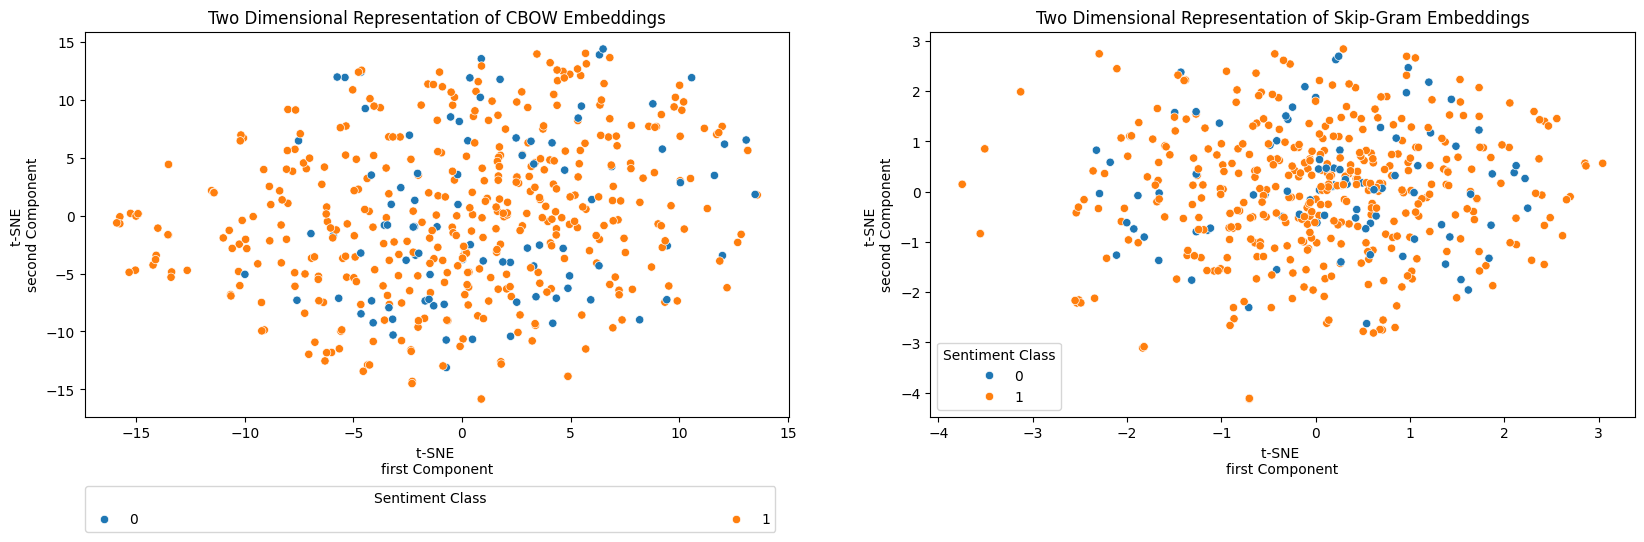

In [17]:
num_samples=500
cbow_reviews_train=w2v_model_cbow.layer(vectorize_layer(x_train_str.iloc[:num_samples])).numpy()
cbow_reviews_train=cbow_reviews_train.reshape(cbow_reviews_train.shape[0],cbow_reviews_train.shape[1]*cbow_reviews_train.shape[2])
cbow_tsne_embeddings = TSNE().fit(cbow_reviews_train)

cbow_tsne_embeddings=pd.DataFrame({'X-Axis':cbow_tsne_embeddings[:,0],
                                   'Y-Axis':cbow_tsne_embeddings[:,1],
                                   'Sentiment Class':y_train[:num_samples]})

skipgram_reviews_train=w2v_model_skipgram.layer(vectorize_layer(x_train_str.iloc[:num_samples])).numpy()
skipgram_reviews_train=skipgram_reviews_train.reshape(skipgram_reviews_train.shape[0],skipgram_reviews_train.shape[1]*skipgram_reviews_train.shape[2])
skipgram_tsne_embeddings = TSNE().fit(skipgram_reviews_train)
skipgram_tsne_embeddings=pd.DataFrame({'X-Axis':skipgram_tsne_embeddings[:,0],
                                       'Y-Axis':skipgram_tsne_embeddings[:,1],
                                        'Sentiment Class':y_train[:num_samples]})


fig,ax=plt.subplots(ncols=2,nrows=1,figsize=(20,5))
sns.scatterplot(x='X-Axis',y='Y-Axis',data=cbow_tsne_embeddings,hue='Sentiment Class',ax=ax[0])
ax[0].set_xlabel('t-SNE \nfirst Component')
ax[0].set_ylabel('t-SNE \nsecond Component')
ax[0].legend(mode='expand',ncols=2,loc=[0.0,-0.3],title='Sentiment Class')
ax[0].set_title('Two Dimensional Representation of CBOW Embeddings')

sns.scatterplot(x='X-Axis',y='Y-Axis',data=skipgram_tsne_embeddings,hue='Sentiment Class',ax=ax[1])
ax[1].set_xlabel('t-SNE \nfirst Component')
ax[1].set_ylabel('t-SNE \nsecond Component')
ax[1].set_title('Two Dimensional Representation of Skip-Gram Embeddings')

plt.show()
plt.close()

FNN models with both embeddings

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


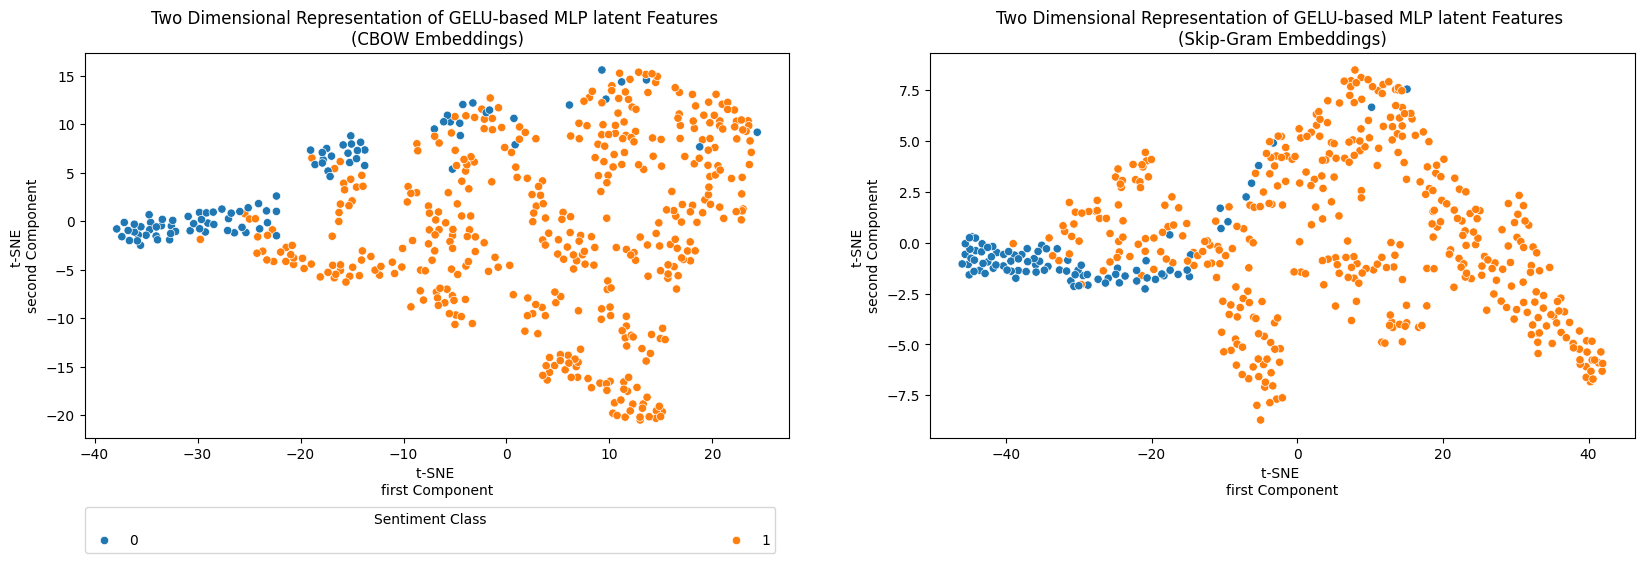

In [18]:
predictions_results_frame=[]

'''
cbow model
'''

cbow_mlp_model = Sequential([
    keras.layers.Input(shape=(1,), dtype= 'string'),
    vectorize_layer,
    keras.layers.Embedding(n_embedding, embeddings_dimension, weights=[w2v_model_cbow.layer.get_weights()[0]]),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(10, activation= 'gelu', kernel_initializer= 'he_normal'),
    keras.layers.Dense(1, activation= 'sigmoid')
])

cbow_mlp_model.compile(loss='binary_crossentropy', optimizer= 'adam')

cbow_mlp_model.fit(x_train_str.astype('string'),
                    y_train,
                    epochs= 10, 
                    batch_size= 32,
                    validation_split= 0.25,
                    verbose=0)
cbow_proba_pr = cbow_mlp_model.predict(x_test_str.astype('string')).flatten()
cbow_class_pr=np.where(cbow_proba_pr >= (np.median(cbow_proba_pr)-0.1) ,1.0 ,0.0)

df_scores['FNN-CBOW'] = [recall_score(y_true=y_test,y_pred=cbow_class_pr), precision_score(y_true=y_test,y_pred = cbow_class_pr), accuracy_score(y_true=y_test,y_pred = cbow_class_pr), roc_auc_score(y_true=y_test,y_score=cbow_proba_pr)]

predictions_results_frame.append([recall_score(y_true=y_test,y_pred=cbow_class_pr),
                                precision_score(y_true=y_test,y_pred=cbow_class_pr),
                                accuracy_score(y_true=y_test,y_pred = cbow_class_pr),
                                roc_auc_score(y_true=y_test,y_score=cbow_proba_pr)])

'''
skipgram model
'''

skipgram_mlp_model = Sequential([
    keras.layers.Input(shape=(1,), dtype= 'string'),
    vectorize_layer,
    keras.layers.Embedding(n_embedding, embeddings_dimension, weights=[w2v_model_skipgram.layer.get_weights()[0]]),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(10, activation= 'gelu', kernel_initializer= 'he_normal'),
    keras.layers.Dense(1, activation= 'sigmoid')
])

skipgram_mlp_model.compile(loss='binary_crossentropy', optimizer= 'adam')

skipgram_mlp_model.fit(x_train_str.astype('string'),
                        y_train,
                        epochs= 10,
                        batch_size= 32,
                        validation_split= 0.25,
                        verbose=0)

skipgram_proba_pr = skipgram_mlp_model.predict(x_test_str.astype('string')).flatten()
skipgram_class_pr=np.where(skipgram_proba_pr >= (np.median(skipgram_proba_pr)-0.1) ,1.0 ,0.0)

df_scores['FNN-skipgram'] = [recall_score(y_true=y_test,y_pred=skipgram_class_pr), precision_score(y_true=y_test,y_pred = skipgram_class_pr), accuracy_score(y_true=y_test,y_pred = skipgram_class_pr), roc_auc_score(y_true=y_test,y_score=skipgram_class_pr)]

predictions_results_frame.append([recall_score(y_true=y_test,y_pred = skipgram_class_pr),
                                accuracy_score(y_true=y_test,y_pred = skipgram_class_pr),
                                precision_score(y_true=y_test,y_pred = skipgram_class_pr),
                                roc_auc_score(y_true=y_test,y_score = skipgram_proba_pr)])


plot_embeddings(num_samples=500,Xclean_train=x_train_str,vectorize_layer=vectorize_layer,
                plot_w2v_embeddings=False,plot_w2v_mlp=False,
                cbow_mlp_model=cbow_mlp_model,skipgram_mlp_model=skipgram_mlp_model)


result for FNN

In [19]:
results_overview=pd.DataFrame(np.around(np.array(predictions_results_frame),4),columns=['Recall Score', 'Accuracy Score', 'Precision Score','ROC Auc Score'],
            index=['FNN-CBOW','FNN-SkipGram'])

print(results_overview)

              Recall Score  Accuracy Score  Precision Score  ROC Auc Score
FNN-CBOW            0.9975          0.8158           0.8160         0.7981
FNN-SkipGram        1.0000          0.8100           0.8096         0.8036


Based on the FNN results, the Skip-Gram embeddings performed slightly better than CBOW. Therefore, we will proceed with Skip-Gram embeddings for all subsequent experiments and model development.

# 4. RNN With Skipgram (as own embedding) and pre-trained embeddings

Helper functions for RNN

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
from gensim.models import KeyedVectors

def padding(tokenizer, input, max_len=None):
    input_int = tokenizer.texts_to_sequences(input.astype('string'))

    if max_len:
        x_train_int_pad = pad_sequences(input_int, max_len)
        return x_train_int_pad
    else:
        max_len = max([len(content) for content in input_int])
        print('The longest review of the training set has {} words is fixed.'.format(max_len))
        x_train_int_pad = pad_sequences(input_int, max_len)
        return x_train_int_pad, max_len

def diag_nn(model, story, x_ts, y_ts, plot_roc=True, plot_loss=True):
    ''' 
        Diagnose fitted keras models by plotting results from the
        story (e.g., development of training loss) and calculating
        classification performance (accuracy & AUC) on the test set
    '''
    
    # Calculate test set predictions
    yhat = model.predict(x_ts)
    
    # Calling our helper for classifier evaluation
    recall, precision, acc, auc, cmat = assess_sentiment_classifier(y_ts, yhat, cut_off=0.5, plot_roc=plot_roc)
    print("NN test set performance:\tRecall={:.4f}\tPrecision={:.4f})\tAccuracy={:.4f}\tAUC={:.4f}".format(recall, precision, acc, auc))
    print('Confusion matrix:')
    print(cmat)

    if plot_loss:
        plt.plot(story.history['loss'])
        plt.plot(story.history['val_loss'])
        plt.title('loss evolution')
        plt.ylabel('loss')
        plt.xlabel('epoch')
        plt.legend(['train', 'validation'], loc='upper left')
        plt.show()
    
    return (recall, precision, acc, auc, cmat) 

# Assess sentiment classification models 
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

def assess_sentiment_classifier(ytest, yhat, cut_off=0.5, plot_roc=True):
    """
        Helper function to assess a classification model in terms of the AUC
        and classification accuracy. We calculate the latter by comapring
        continuous (e.g., probabilistic) classifier predictions to a cut_off.
        Cases where the prediction exceeds the cut-off are classified as 
        positive.
    """
    # Calculate discrete class predictions
    try:
        yhat_c = np.where(yhat>cut_off, 1, 0)
    except:
        yhat_c = np.where(pd.DataFrame(yhat)>cut_off, 1, 0)
    
    # Calculate classification accuracy and AUC
    recall = recall_score(ytest,yhat_c)
    precision = precision_score(ytest, yhat_c)
    acc = accuracy_score(ytest, yhat_c)
    auc = roc_auc_score(ytest, yhat)
    
    
    # Confusion matrix 
    cmat = confusion_matrix(ytest, yhat_c)
    
    # ROC analysis
    if plot_roc==True:
        fpr, tpr, _ = roc_curve(ytest, yhat)
        plt.plot(fpr,tpr, label="AUC={:.4}".format(auc));
        plt.plot([0, 1], [0, 1], "r--")
        plt.ylabel('True positive rate')    
        plt.xlabel('False positive rate')    
        plt.legend(loc='lower right')
        plt.show()
    
    return(recall, precision, acc, auc, cmat)


def get_embedding_matrix(tokenizer, pretrain, vocab_size, verbose=0):
    '''
        Helper function to construct an embedding matrix for
        the focal corpus based on some pre-trained embeddings.
    '''
    # Initialize embedding matrix
    emb_mat = np.zeros((vocab_size, 300))
    oov_words = []
    v = len(tokenizer.word_index)
    print('Start embedding process for {} words.'.format(v), flush=True)

    for word, i in tokenizer.word_index.items():
        # try-catch together with a zero-initilaized embedding matrix achieves our rough fix for oov words
        try:
            emb_mat[i] = pretrain[word]
        except:
            oov_words.append(word)

    print('Created embedding matrix of shape {}'.format(emb_mat.shape))

    print('Encountered {} out-of-vocabulary words.'.format(len(oov_words)))
    return (emb_mat, oov_words)

def load_glove_embeddings(glove_path, embedding_dim=100):
    embeddings_index = {}
    with open(glove_path, encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = vector
    print(f"Loaded {len(embeddings_index)} word vectors from GloVe.")
    return embeddings_index


Data conversion for a proper format, including tokenization and padding

In [21]:
tok = Tokenizer(n_embedding, oov_token=1)
tok.fit_on_texts(x_train_str.astype('string')) 

x_train_int_pad, max_len_content = padding(tok, x_train_str)
x_test_int_pad = padding(tok, x_test_str, max_len_content)
x_train_int_pad.shape, y_train.shape, x_test_int_pad.shape, y_test.shape

The longest review of the training set has 33 words is fixed.


((1500, 33), (1500,), (500, 33), (500,))

## Building RNN with Gated Recurrent Unit and own/custom trained embedding 

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


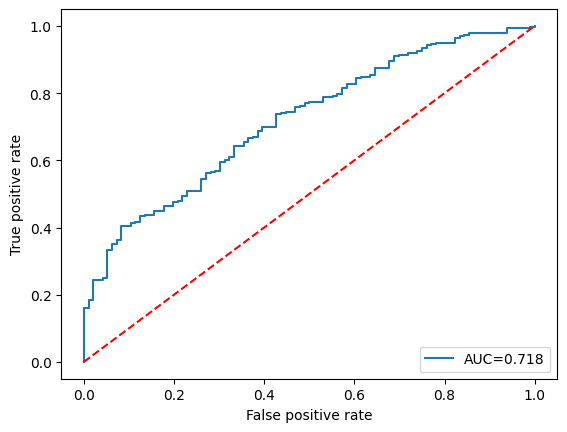

NN test set performance:	Recall=0.9802	Precision=0.8165)	Accuracy=0.8060	AUC=0.7180
Confusion matrix:
[[  7  89]
 [  8 396]]


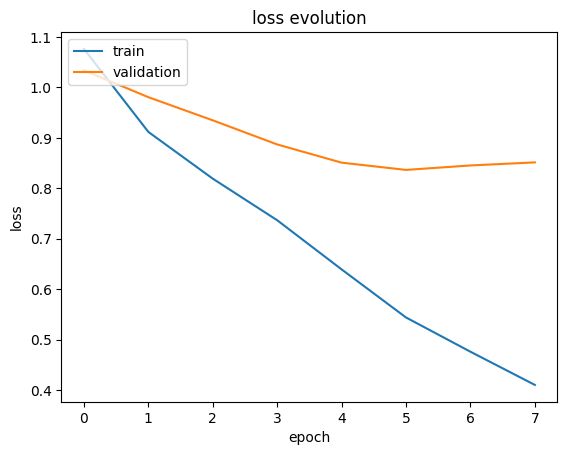

In [22]:
gru = Sequential()
gru.add(keras.layers.Embedding(n_embedding, 
                               embeddings_dimension, 
                               weights=[w2v_model_skipgram.layer.get_weights()[0]]))
gru.add(keras.layers.GRU(8))
gru.add(keras.layers.Dropout(0.3))  
gru.add(keras.layers.Dense(5, activation= 'relu', kernel_initializer= 'he_normal', kernel_regularizer=l2(0.05)))
gru.add(keras.layers.Dense(1, activation= 'sigmoid'))

gru.compile(optimizer='adam', loss='binary_crossentropy',  metrics=['accuracy'])
# gru.layers[2].set_weights([embedding_matrix_skipgram])


early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

summary = gru.fit(x_train_int_pad,
                   y_train, 
                   batch_size= 32, 
                   epochs=50, 
                   validation_split=0.25,
                   verbose= False,
                   callbacks=[early_stop])

recall, precision, acc, auc, _ = diag_nn(gru, summary, x_test_int_pad, y_test, plot_roc=True, plot_loss=True)

df_scores['RNN-own embedding'] = [recall, precision, acc, auc]

## Building RNN with Gated Recurrent Unit and pre-trained embedding (Glove)

Extracting the glove embedding

In [23]:
glove_index = load_glove_embeddings(path_pretrained_embedding, embedding_dim=100)
glove_embedding, _ = get_embedding_matrix(tok, glove_index, n_embedding)

Loaded 400000 word vectors from GloVe.
Start embedding process for 3997 words.
Created embedding matrix of shape (3998, 300)
Encountered 465 out-of-vocabulary words.


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


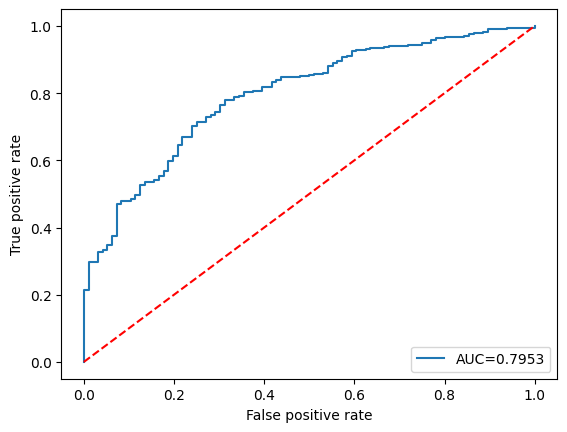

NN test set performance:	Recall=0.9678	Precision=0.8337)	Accuracy=0.8180	AUC=0.7953
Confusion matrix:
[[ 18  78]
 [ 13 391]]


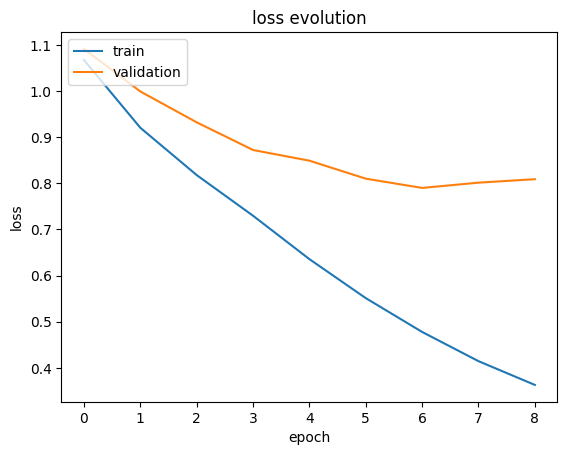

In [24]:
gru_glove = Sequential()
gru_glove.add(keras.layers.Embedding(n_embedding, 
                               embeddings_dimension, 
                               weights=[glove_embedding] ))
gru_glove.add(keras.layers.GRU(8))
gru_glove.add(keras.layers.Dropout(0.3))  
gru_glove.add(keras.layers.Dense(5, activation= 'relu', kernel_initializer= 'he_normal', kernel_regularizer=l2(0.05)))
gru_glove.add(keras.layers.Dense(1, activation= 'sigmoid'))

gru_glove.compile(optimizer='adam', loss='binary_crossentropy',  metrics=['accuracy'])
# gru.layers[2].set_weights([embedding_matrix_skipgram])


early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

summary = gru_glove.fit(x_train_int_pad,
                   y_train, 
                   batch_size= 32, 
                   epochs=50, 
                   validation_split=0.25,
                   verbose= False,
                   callbacks=[early_stop])

recall, precision, acc, auc, _ = diag_nn(gru_glove, summary, x_test_int_pad, y_test, plot_roc=True, plot_loss=True)

df_scores['RNN-glove embedding'] = [recall, precision, acc, auc]

# 5. Transformers

Helper functions for Transformers, both inference and fine tuning

In [25]:
import torch
import torch.nn.functional as F
from transformers import pipeline
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments


if torch.backends.cuda.is_built() and torch.cuda.is_available():
    device = torch.device('cuda') # for NVIDIA GPUs
elif torch.backends.mps.is_built():
    device = torch.device('mps') # for Apple Silicon Macs
else:
    device = torch.device('cpu')



def pipeline_classify(data):
    ''' Function to run the sentiment analysis pipeline on each row of a dataset
    and extract the scores AND probabilities. '''

    predictions = []
    probabilities = []
    
    for text in data:
        result = classifier(text, truncation=True, return_all_scores=True)
        
        scores = result[0]

        pos_score = None
        neg_score = None
        
        for score_dict in scores:
            if score_dict['label'] == 'POSITIVE':
                pos_score = score_dict['score']
            elif score_dict['label'] == 'NEGATIVE':
                neg_score = score_dict['score']
        
        # Determine prediction based on higher score
        if pos_score > neg_score:
            pred_class = 1
            prob_positive = pos_score
        else:
            pred_class = 0
            prob_positive = pos_score
        
        predictions.append(pred_class)
        probabilities.append(prob_positive)
    
    return predictions, probabilities


class dataset_converter(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.X.items()}
        item['labels'] = torch.tensor(self.Y[idx])
        return item
    

class DistilBertWrapper:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer
    
    def predict_batch(self, sentences, batch_size=32):
        predictions = []
        probabilities = []  # Add this to store probabilities
        device = next(self.model.parameters()).device
        self.model.eval()
        
        for i in range(0, len(sentences), batch_size):
            batch = sentences[i:i+batch_size]
            encodings = self.tokenizer(batch, truncation=True, padding=True, return_tensors='pt')
            input_ids = encodings['input_ids'].to(device)
            attention_mask = encodings['attention_mask'].to(device)
            
            with torch.no_grad():
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
            
            logits = outputs.logits
            probs = F.softmax(logits, dim=1)
            batch_preds = torch.argmax(probs, dim=1).cpu().numpy()
            batch_probs = probs[:, 1].cpu().numpy()
            
            predictions.extend(batch_preds)
            probabilities.extend(batch_probs)
        
        return predictions, probabilities 


/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/dev/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Untuned pre-trained Transformers

Device set to use mps:0
/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/dev/venv/lib/python3.9/site-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


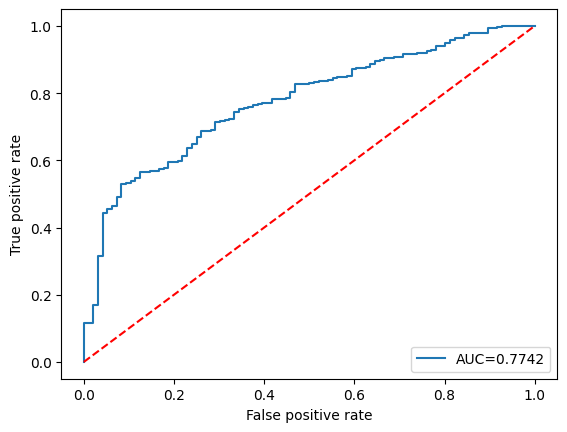

In [26]:
classifier = pipeline('sentiment-analysis', model = 'distilbert/distilbert-base-uncased-finetuned-sst-2-english')
predictions, probabilities = pipeline_classify(x_test_str)

recall, precision, acc, auc, _ = assess_sentiment_classifier(y_test, probabilities)
df_scores['DistilBert_untrained'] = [recall, precision, acc, auc]

### Tuning for pre-trained Transformers

In [27]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
untuned_bert_model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

x_train_transformers = tokenizer(x_train_str.tolist(), truncation=True, padding='max_length')
x_test_transformers = tokenizer(x_test_str.tolist(), truncation=True, padding='max_length')

train_dataset = dataset_converter(x_train_transformers, y_train.to_list())
test_dataset = dataset_converter(x_test_transformers, y_test.to_list())

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    seed=111,
    data_seed=111
    )

tuned_bert_model = Trainer(
    model=untuned_bert_model,
    args=training_args,
    train_dataset=train_dataset
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [28]:
tuned_bert_model.train()

/Users/benedikt/Documents/Master/SoSe 25/Deep Learning for Text Analytics/dev/venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss


TrainOutput(global_step=188, training_loss=0.5421519178025266, metrics={'train_runtime': 562.7459, 'train_samples_per_second': 5.331, 'train_steps_per_second': 0.334, 'total_flos': 397402195968000.0, 'train_loss': 0.5421519178025266, 'epoch': 2.0})

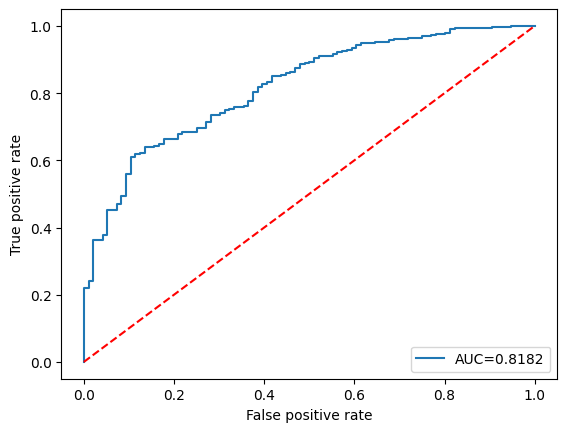

In [29]:
distilbert = DistilBertWrapper(tuned_bert_model.model, tokenizer)

predictions, probabilities = distilbert.predict_batch(x_test_str.tolist())

recall, precision, acc, auc, _ = assess_sentiment_classifier(y_test, probabilities)
df_scores['DistilBert_tuned'] = [recall, precision, acc, auc]

In [30]:
# Create comprehensive results summary
import pandas as pd

# Combine all results into one comprehensive dataframe
all_results = {}

# Add dictionary-based results from 'result' dictionary
for method_name, metrics in result.items():
    all_results[method_name] = [
        metrics.get('recall', 'N/A'),
        metrics.get('precision', 'N/A'), 
        metrics.get('accuracy', 'N/A'),
        metrics.get('roc_auc', 'N/A')
    ]

# Add results from df_scores (FNN, RNN, Transformer results)
if 'df_scores' in locals():
    for column in df_scores.columns:
        all_results[column] = df_scores[column].tolist()

# Create final comprehensive results dataframe
final_results = pd.DataFrame(
    all_results, 
    index=['Recall', 'Precision', 'Accuracy', 'ROC_AUC']
).T

print("=" * 80)
print("COMPREHENSIVE SENTIMENT ANALYSIS RESULTS SUMMARY")
print("=" * 80)
print(final_results.round(4))

COMPREHENSIVE SENTIMENT ANALYSIS RESULTS SUMMARY
                        Recall Precision  Accuracy   ROC_AUC
logit_tfidf                1.0  0.811245     0.812   0.85641
xgb_tfidf             0.990099  0.824742     0.822  0.691032
logit_count           0.972772  0.852495     0.842  0.846122
xgb_count             0.987624  0.826087     0.822  0.751715
lm                    0.670185  0.933824  0.720703       N/A
vader_base            0.873762   0.89029   0.81543       N/A
vader_updated         0.878021   0.89554   0.82208       N/A
vader_BuildIn_Func    0.578689  0.886935  0.597333  0.491658
FNN-CBOW              0.997525  0.815789     0.816  0.798087
FNN-skipgram               1.0  0.809619      0.81  0.505208
RNN-own embedding     0.980198  0.816495     0.806  0.717976
RNN-glove embedding   0.967822  0.833689     0.818  0.795276
DistilBert_untrained  0.472772  0.964646      0.56  0.774237
DistilBert_tuned           1.0     0.808     0.808  0.818172
